# EDA - UHPC Dataset

This notebook performs exploratory data analysis on the Ultra High Performance Concrete (UHPC) dataset, including data cleaning, column selection, and encoding strategy identification.

In [2]:
import pandas as pd
import numpy as np
import re

import json
with open('config.json', 'r') as f:
    config = json.load(f)

from helpers.cleaning import (
    load_raw_uhpc,
    filter_columns,
    clean_basic_types,
    standardize_fiber_types,
    standardize_curing_method,
    standardize_cement_type,
    standardize_sp_type,
    check_unique,
    build_encoding_report,
)

In [3]:
# Load and clean UHPC dataset (multi-level header, column renaming, numeric coercion)
df = load_raw_uhpc(config)
print(f"Cleaned shape: {df.shape}")
print(f"Total columns: {len(df.columns)}")
df.head()

Cleaned shape: (2188, 87)
Total columns: 87


,cement,cement_type,cement_grade,silica_fume,fly_ash,fly_ash_type,limestone_powder,quartz_powder,glass_powder,rice_husk_ash,...,water_absorption,shrinkage_standard,shrinkage_28d,shrinkage_56d,freeze_thaw_standard,freeze_thaw_cycles,rcpt_standard,rcpt,resistivity_standard,surface_resistivity
0,839.0,Type I/II low-alkali portland cement,NaN,104.0,104.0,Class-F,0.0,0.0,0.0,0.0,...,NaN,ASTM C157,270.0,371.0,ASTM C666,105.0,ASTM C1202,165.0,AASHTO T 358,386.0
1,839.0,Type I/II low-alkali portland cement,NaN,104.0,52.0,Class-F,0.0,0.0,0.0,0.0,...,NaN,ASTM C157,242.0,317.0,ASTM C666,106.0,ASTM C1202,142.0,AASHTO T 358,424.0
2,839.0,Type I/II low-alkali portland cement,NaN,104.0,26.0,Class-F,0.0,0.0,0.0,0.0,...,NaN,ASTM C157,223.0,290.0,ASTM C666,106.0,ASTM C1202,136.0,AASHTO T 358,463.0
3,839.0,Type I/II low-alkali portland cement,NaN,104.0,0.0,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,839.0,Type I/II low-alkali portland cement,NaN,104.0,52.0,Class-F,0.0,0.0,0.0,0.0,...,NaN,ASTM C157,231.0,286.0,ASTM C666,106.0,ASTM C1202,135.0,AASHTO T 358,437.0


## 1. Data Loading & Cleaning

In [4]:
# Check data types
print("Data types summary:")
print(df.dtypes.value_counts())
print(f"\nMissing values:\n{df.isnull().sum().sum()} total missing values")

Data types summary:
float64    57
str        30
Name: count, dtype: int64

Missing values:
111322 total missing values


## 2. Data Inspection & Filtering

In [5]:
# Remove rows with missing target variable and drop unused columns (focusing on cs_28d as target)
df = filter_columns(df, config)
print(f"Final shape after filtering: {df.shape}")
print(f"Remaining columns: {df.shape[1]}")

Final shape after filtering: (2073, 43)
Remaining columns: 43


In [6]:
# Data type conversions for curing_pressure, fly_ash/slag/filler/sand types and fiber2
df = clean_basic_types(df)

In [7]:
# Standardize fiber1_type / fiber2_type into a fixed set of categories
df = standardize_fiber_types(df)

In [8]:
# Standardize curing_method into a fixed set of categories
df = standardize_curing_method(df)

### Curing Method Categorization

In [9]:
# Check unique values
check_unique(df, 'cement_type')

Unique cement_type values:
['Type I/II low-alkali portland cement', 'Portland cement ', ' Portland cement', 'High sulfate-resistant cement (Type HS cement)', 'Ordinary Portland cement\nASTM C150 type I', 'Portland cement CEM I 52.5 N', ' Portland cement (US) Type I', 'Portland cement CEM I 52.5 R', 'Portland cement type I 52.5 R', 'Type I portland cement', 'CEM I 52.5 PM ES', 'CEMII/A-L42.5R', 'ordinary Portland cement Type I cement', 'portland cement', 'Portland cement Type 1 cement', 'Type III portland cement', 'P.I 42.5 Portland cement', 'ordinary portland cement', 'Portland cement type I 52.5R', 'CEM I-type 42.5 R', 'ordinary Portland cement  42.5 Grade ', 'Type I Portland cement', 'Chinese standard Graded 52.5 P.II type Portland cement', 'Ordinary Portland Cement', 'Portland cement (P.I 42.5) ', 'Type 1 Portland cement', 'CEM II 52.5 R', 'Ordinary Portland\nCement (OPC, P.II 52.5)', '52.5 cement', 'Portland cement (CEM 1) with a strength class 52.5 N ', 'Portland cement (CEM 1) wi

### Check Unique Values Helper

### Fiber Type Categorization

In [10]:
# Standardize cement_type via regex classification, then resolve ambiguous grades using cement_grade
df = standardize_cement_type(df)
print(df['cement_type'].value_counts(dropna=False))

cement_type
OPC_52.5           698
OPC_I              560
OPC_42.5           456
HS_cement          158
OPC_53              92
CEM_II              33
OPC_III             32
Unknown             19
white_cement        14
pozzolan_cement      7
OPC_I_GGBS           3
BFS_cement           1
Name: count, dtype: int64


### Cement Type Standardization with Regex

### Combined Cement Type & Grade Cleaning

In [11]:
# Standardize sp_type via regex classification
df = standardize_sp_type(df)
print(df['sp_type'].value_counts(dropna=False))

sp_type
PCE_SP              1159
PCE_HRWRA            398
Unspecified          218
HRWRA                125
NaN                  120
SNF_SP                26
Other_Polymer_SP      23
VMA                    4
Name: count, dtype: int64


### Superplasticizer Type Standardization

## 3. Feature Encoding Strategy Analysis

In [12]:
# Analyze encoding requirements for each feature
encoding_df = build_encoding_report(df, out_path="encoding_report.csv")

print(f"Total features to encode: {len(encoding_df)}\n")
display(encoding_df)
print("\n✓ Encoding report saved to 'encoding_report.csv'")

Total features to encode: 43



,Column,Data Type,Unique Values,Type of Encoding
0,cement,float64,359,No Encoding
1,cement_type,str,12,Ordinal/Target Encoding
2,cement_grade,float64,3,No Encoding
3,silica_fume,float64,247,No Encoding
4,fly_ash,float64,102,No Encoding
5,fly_ash_type,str,2,Binary Encoding
6,limestone_powder,float64,44,No Encoding
7,quartz_powder,float64,87,No Encoding
8,glass_powder,float64,95,No Encoding
9,rice_husk_ash,float64,19,No Encoding



✓ Encoding report saved to 'encoding_report.csv'


## 4. Data Type Summary

In [13]:
# Check for categorical (object) columns
object_cols = [col for col in df.columns if df[col].dtype == 'object']

print(f"Categorical columns ({len(object_cols)}):\n")
for col in object_cols:
    print(f"{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())
    print()
    
df.to_csv(config["initial_cleaned_filepath"])

df.shape

Categorical columns (0):



(2073, 43)

### Categorical Columns Summary

In [14]:
# Coefficient of variation / skewness / outlier summary for float columns
from helpers.eda import numeric_summary_table

float_cols = df.select_dtypes(include=['float']).columns
df_float = df[float_cols]

summary = numeric_summary_table(df)
print(summary)

                            mean   median     std     min      max  cv (%)  \
cement                    786.19   788.50  202.38  170.00  1856.70    25.7   
cement_grade               48.93    52.50    4.83   42.50    53.00     9.9   
silica_fume               180.80   197.10   90.04    0.00   617.65    49.8   
fly_ash                    59.57     0.00  143.84    0.00  1152.00   241.5   
limestone_powder           13.61     0.00   62.88    0.00  1058.20   462.0   
quartz_powder              58.90     0.00  113.37    0.00   528.00   192.5   
glass_powder               32.36     0.00  123.65    0.00  1067.00   382.1   
rice_husk_ash               2.34     0.00   22.75    0.00   481.06   971.8   
metakaolin                  4.90     0.00   31.73    0.00   510.00   647.4   
ggbfs                      42.03     0.00  141.93    0.00   768.00   337.7   
slag                       17.08     0.00   97.26    0.00  1100.00   569.5   
nano_caco3                  0.54     0.00    4.15    0.00    69.

### Coefficient of Variation Analysis

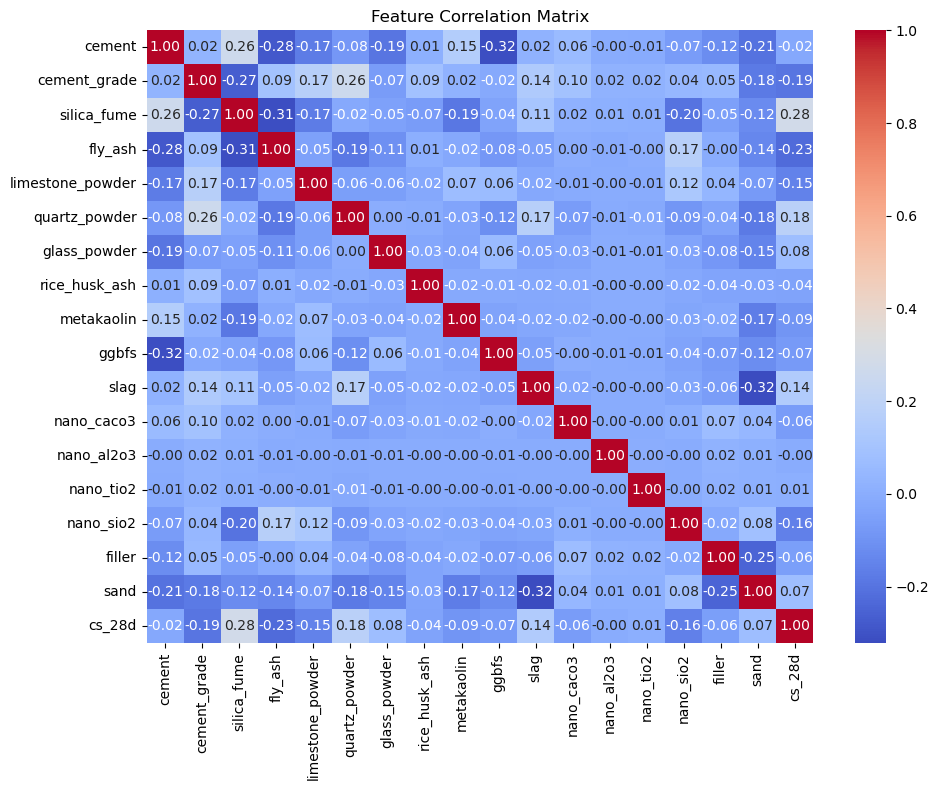

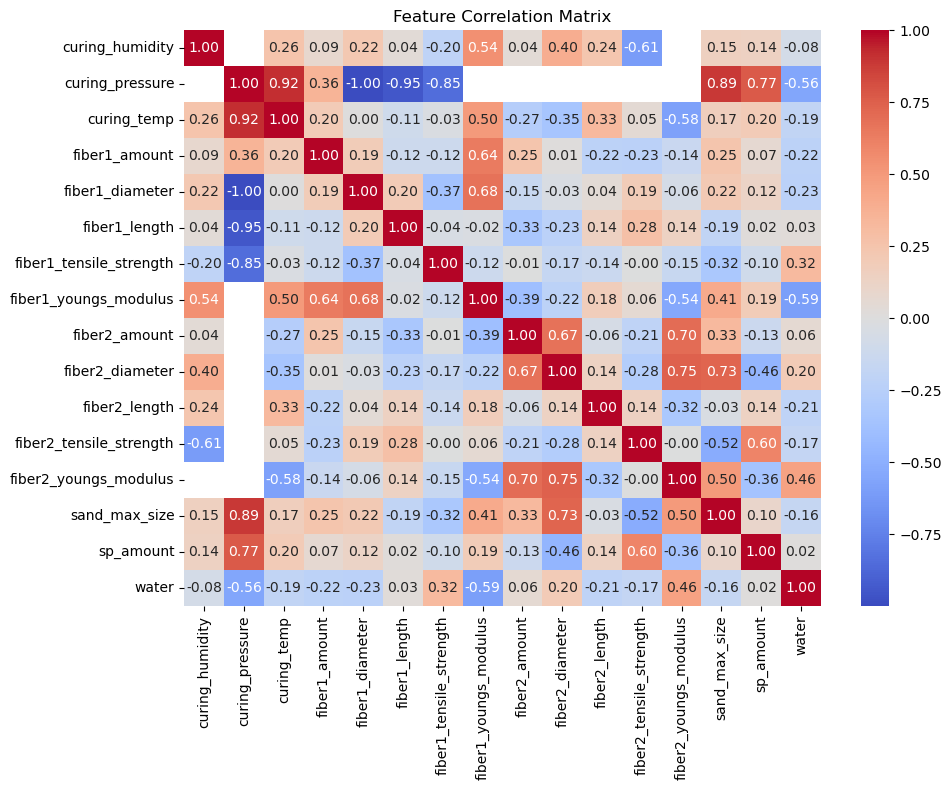

In [15]:
import sys
sys.path.insert(0, '../Week-2-3-4')

from utils.plotting import plot_correlation_matrix

# First half of columns + last column
n_cols = len(df_float.columns)
cols_to_select = list(df_float.columns[:n_cols//2]) + [df_float.columns[-1]]
plot_correlation_matrix(df_float[cols_to_select], figsize=(10, 8), cmap="coolwarm", title="Feature Correlation Matrix")

# Remaining columns
rest_cols = df_float.columns.difference(cols_to_select)
plot_correlation_matrix(df_float[rest_cols], figsize=(10, 8), cmap="coolwarm", title="Feature Correlation Matrix")

In [16]:
df['cs_28d'].describe()

count    2073.000000
mean      150.192753
std        36.365367
min        80.000000
25%       124.850000
50%       145.100000
75%       170.000000
max       298.000000
Name: cs_28d, dtype: float64

In [25]:

cv_cs_28d = (df['cs_28d'].std() / df['cs_28d'].mean() * 100).round(1)


print(f'cv of cs28d: { cv_cs_28d}')
print("Skewness:", df['cs_28d'].skew())
print("Kurtosis:", df['cs_28d'].kurt())

cv of cs28d: 24.2
Skewness: 0.7173491398736052
Kurtosis: 0.5993310500510143
